In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import re
from pathlib import Path
from pandas.errors import EmptyDataError
from sklearn.preprocessing import OneHotEncoder


import src.preprocessing as pre
import src.features as feat
import src.modeling as mod

In [2]:
x = "/Users/arthu/Documents/Marseille/aMU/M1/Stage/data/CTR/Export_pupille_CTR_55_F_77ANS_Benson2_2024-09-04_12-03-20.csv"
df = pd.read_csv(x, sep=';', skiprows=21, encoding='latin-1').drop(columns='Unnamed: 10')

split = re.split(r'_| ', str(x))
df['condition'] = split[2]
df['id'] = split[3]

# df = df.drop(columns=['Time (ms)', 'Unnamed: 10'])
# data_all = pd.read_csv("/Users/arthu/Documents/Marseille/aMU/M1/Stage/2026_06_19_data1.csv", sep=',', encoding='latin-1')

In [16]:
df.head()

,Time (ms),LX (deg),LY (deg),RX (deg),RY (deg),LDX (pix),LDY (pix),RDX (pix),RDY (pix),Label,condition,id
0,2,2.309,2.881,-4.843,1.742,267,226,238,202,consignes=on,CTR,55
1,5,2.309,2.881,-4.844,1.834,267,229,240,204,NaN,CTR,55
2,8,2.365,2.968,-4.844,1.834,270,231,238,197,NaN,CTR,55
3,12,2.369,2.878,-4.843,1.742,270,229,240,202,NaN,CTR,55
4,15,2.309,2.881,-4.844,1.834,270,224,238,197,NaN,CTR,55


In [57]:
current_dir = Path.cwd()
project_dir = current_dir.parent.parent
PCA_dir = project_dir / "data/ACP"
AMN_dir = project_dir / "data/AMN"
DFT_dir = project_dir / "data/DFT"
CTR_dir = project_dir / "data/CTR"

In [ ]:
# def smooth_explore(data, column, lfreq):
#     df_smooth = data.copy()
#     for trial in data['trial'].unique():
#         for col in column:
#             sos = sp.signal.butter(5, Wn=lfreq, fs=300, btype='low', output='sos')
#             df_smooth[df_smooth['trial']==trial].loc[:, col] = sp.signal.sosfiltfilt(sos, df_smooth[df_smooth['trial']==trial].loc[:, col])
#     return df_smooth

In [5]:
def find_bad_signals_explore(data, stim_windows, column):
    removed = 0
    total = 0
    for col in column:
        data.loc[:, f'{col}_removed'] = 0
        for i, v in enumerate(stim_windows):
            # print(f'col: {col}, trial: {i}, max: {(pupil_diam.loc[v[0]:v[1], col].diff()/pupil_diam.loc[v[0]:v[1], 'time'].diff()).abs().max()}')
            if data.loc[v[0]:v[1], col].mean() > 0:
                data.loc[v[0]:v[1], f'{col}_removed']=1
                # data.loc[v[0]:v[1], col] = np.nan
            if (data.loc[v[0]:v[1], col].diff()/data.loc[v[0]:v[1], 'time'].diff()).abs().max() > 1500:
                data.loc[v[0]:v[1], f'{col}_removed']=1
                # data.loc[v[0]:v[1], col] = np.nan
            # if data.loc[v[0]:v[1], col].abs().max() > data.loc[v[0]:v[0]+800, col].abs().max()*1.15:
            #     data.loc[v[0]:v[1], f'{col}_removed']=1
            #     # data.loc[v[0]:v[1], col] = np.nan


    return data

In [214]:
# columns = ['LDX (pix)', 'LDY (pix)', 'RDX (pix)', 'RDY (pix)']
# test = remove_bad_signals(test, columns, threshold=0.4)

In [3]:
def average_timeseries(data, columns):
    x = np.linspace(0, 1792/300, 1792)
    pps_data = pd.DataFrame(columns=columns)
    
    for i in data.loc[:, 'valence'].unique():
        for j in data.loc[:, 'category'].unique():
            time_series = data[(data['category']==j) & (data['valence']==i)].groupby('time')['RDX (pix)'].mean().reset_index()
            if len(time_series):
                local = pd.DataFrame(columns=columns)
                local['time']=x
                local['time_series']=time_series.loc[:, 'RDX (pix)']
                local['category']=np.repeat(j, 1792)
                local['valence']=np.repeat(i, 1792)
                local['condition']=np.repeat(condition, 1792)
                pps_data = pd.concat([pps_data, local], ignore_index=True)

    return pps_data

In [6]:
split = re.split(r'_| ', str(x))
columns = ['LDX (pix)', 'LDY (pix)', 'RDX (pix)', 'RDY (pix)']
stim_windows = pre.extract_windows(df)
order_stim = pre.extract_stim(df, stim_windows)

pupil_diam = pre.remove_blink(df.loc[:, columns], stim_windows)
pupil_diam = pre.add_stim_columns(pupil_diam, stim_windows, order_stim, trial_len=1792, sampling_rate=300)
pupil_diam = pre.smooth(pupil_diam, stim_windows, columns, lfreq=15)
pupil_diam = pre.baseline_correct(pupil_diam, stim_windows, columns)
pupil_diam = find_bad_signals_explore(pupil_diam, stim_windows, columns)
pupil_diam = pre.trials_only(pupil_diam)
pupil_diam['id'] = int(split[3])
pupil_diam = pre.remove_bad_signals(pupil_diam, columns, threshold=0.35)
pupil_diam = pre.one_hot_encoder(pupil_diam)
pupil_diam = pupil_diam.groupby(['valence', 'category', 'time']).mean().reset_index().drop(columns=['trial', 'valence', 'category'])

pupil_diam['condition'] = split[2]

In [4]:
# sns.relplot(pupil_diam, x='time', y='RDX (pix)', row='category', col='valence', hue='valence', kind='line')

In [5]:
# col='RDX (pix)'

# sns.relplot(pupil_diam, x='time', y=col, col='trial', col_wrap=4, kind='line', hue=f'{col}_removed', facet_kws={'sharey': False})
# plt.tight_layout()

### Model

In [67]:
def model_fit(x, y):
    x = np.linspace(0, len(y)/300, len(y))
    gmodel = Model(mod.sim_func)
    params = gmodel.make_params()

    params['D_1'].set(value=250.0, min=0.0, max=2000)
    params['t_0'].set(value=0.3, min=0.0, max=6.0)
    params['tau_1'].set(value=1.0, min=0.01, max=50.0)
    params['tau_2'].set(value=0.8, min=0.01, max=50.0)
    
    result = gmodel.fit(y, params, t=x, D_0=y[0], weights=np.repeat([20.0, 0.2], [300, 1492]))

    # plt.plot(x, y, '-')
    # plt.plot(x, result.init_fit, '--', label='initial fit')
    # plt.plot(x, result.best_fit, '-', label='best fit')
    # plt.legend()
    # sns.despine()
    # plt.show()
    
    return result.best_values

In [ ]:
from lmfit import Model

x = np.linspace(0, 1792/300, 1792)
y = pupil_diam[(pupil_diam.valence=='negative') & (pupil_diam.category=='visage')]['RDX (pix)']

gmodel = Model(mod.sim_func)
params = gmodel.make_params()

params['D_1'].set(value=250.0, min=0.0)
params['t_0'].set(value=0.3, min=0.0)
params['tau_1'].set(value=1.0, min=0.0)
params['tau_2'].set(value=0.8, min=0.0)

result = gmodel.fit(y, params, t=x, D_0=y[0], weights=np.repeat([20.0, 0.2], [300, 1492]))

print(result.fit_report())

plt.plot(x, y, '-')
plt.plot(x, result.init_fit, '--', label='initial fit')
plt.plot(x, result.best_fit, '-', label='best fit')
plt.legend()
sns.despine()
plt.show()

### Extract all parameters

In [66]:
def extract_params(file, condition):
    column_names=['id', 'condition', 'valence', 'category', 'latency', 'mean_variation', 'max_diam', 'D_1', 't_0', 'tau_1', 'tau_2']
    data = pd.DataFrame(columns=column_names)
    for i, x in enumerate(file.iterdir()):
        # import data
        print(f'starting {i}')
        try:
            df = pd.read_csv(x, sep=';', skiprows=21, encoding='latin-1')
            split = re.split(r'_| ', str(x))
            id_pps = f'{split[2]}_{split[3]}'
            print(f'file: {x}, id: {id_pps}')
            columns = list(df.columns.values)[5:9]
            stim_windows = extract_windows(df)
            order_stim = extract_stim(df, stim_windows)

            pupil_diam = remove_blink(df.loc[:, columns], stim_windows)
            pupil_diam = add_stim_columns(pupil_diam, stim_windows, order_stim, trial_len=1792, freq=300)
            pupil_diam = smooth(pupil_diam, stim_windows, columns, lfreq=15)
            pupil_diam = baseline_correct(pupil_diam, stim_windows, columns)
            pupil_diam = remove_bad_signals(pupil_diam, stim_windows, columns)
            pupil_diam = trials_only(pupil_diam)

            unique_trials = pupil_diam.loc[:, 'trial'].drop_duplicates()

            for i in (unique_trials):
                c = pupil_diam.loc[:, 'category'][pupil_diam.loc[:, 'trial']==i].drop_duplicates().iloc[0]
                v = pupil_diam.loc[:, 'valence'][pupil_diam.loc[:, 'trial']==i].drop_duplicates().iloc[0]
                mean_pupil = mean(pupil_diam, category=c, valence=v, eye='RDX (pix)')
                params = model_fit(pupil_diam.loc[:, 'time'][pupil_diam['trial']==0], mean_pupil)
                data.loc[len(data)] = [id_pps, condition, v, c, latency(mean_pupil), mean_variation(mean_pupil), max_diam(mean_pupil), params['D_1'], params['t_0'], params['tau_1'], params['tau_2']]
                
        except EmptyDataError:
            print(x)

    return data

In [202]:
def extract_timeseries(file, condition, threshold):
    new_columns=['valence', 'category', 'time', 'LDX (pix)', 'LDY (pix)', 'RDX (pix)', 'RDY (pix)', 'condition', 'id']
    columns = ['LDX (pix)', 'LDY (pix)', 'RDX (pix)', 'RDY (pix)']
    pps_data = pd.DataFrame(columns=new_columns)
    for i, x in enumerate(file.iterdir()):
        # import data
        print(f'starting {i}')
        try:        
            df = pd.read_csv(x, sep=';', skiprows=21, encoding='latin-1')
            # split = re.split(r'_| ', str(x))
            # id_pps = f'{split[2]}_{split[3]}'
            # print(f'file: {x}, id: {id_pps}')
            # columns = list(df.columns.values)[5:9]
            # stim_windows = extract_windows(df)
            # order_stim = extract_stim(df, stim_windows)

            # pupil_diam = remove_blink(df.loc[:, columns], stim_windows)
            # pupil_diam = add_stim_columns(pupil_diam, stim_windows, order_stim, trial_len=1792, freq=300)
            # pupil_diam = smooth(pupil_diam, stim_windows, columns, lfreq=15)
            # pupil_diam = baseline_correct(pupil_diam, stim_windows, columns)
            # pupil_diam = remove_bad_signals(pupil_diam, stim_windows, columns)

            # pupil_diam = pupil_diam.groupby(['valence', 'category', 'time']).mean().reset_index()
            # pps_data = pd.concat([pps_data, pupil_diam], ignore_index=True)

            stim_windows = extract_windows(df)
            order_stim = extract_stim(df, stim_windows)
            
            pupil_diam = remove_blink(df.loc[:, columns], stim_windows)
            pupil_diam = add_stim_columns(pupil_diam, stim_windows, order_stim, trial_len=1792, freq=300)
            pupil_diam = smooth(pupil_diam, stim_windows, columns, lfreq=15)
            pupil_diam = baseline_correct(pupil_diam, stim_windows, columns)
            pupil_diam = find_bad_signals_explore(pupil_diam, stim_windows, columns)
            pupil_diam = trials_only(pupil_diam)
            # pupil_diam = remove_bad_signals(pupil_diam, columns, threshold=0.35)
            # pupil_diam = pupil_diam.groupby(['valence', 'category', 'time']).mean().reset_index().drop(columns='trial')
            
            split = re.split(r'_| ', str(x))
            pupil_diam['condition'] = split[2]
            pupil_diam['id'] = int(split[3])

            pps_data = pd.concat([pps_data, pupil_diam], ignore_index=True)
            
        except EmptyDataError:
            print(x)

    pps_data = remove_bad_signals(pps_data, columns, threshold=threshold)
    return pps_data

In [218]:
current_dir = Path.cwd()
project_dir = current_dir.parent.parent
PCA_dir = project_dir / "data/ACP"
AMN_dir = project_dir / "data/AMN"
DFT_dir = project_dir / "data/DFT"
CTR_dir = project_dir / "data/CTR"

In [ ]:
pca_data = extract_timeseries(PCA_dir, 'PCA', 0.5)
amn_data = extract_timeseries(AMN_dir, 'AMN', 0.5)
dft_data = extract_timeseries(DFT_dir, 'DFT', 0.5)
ctr_data = extract_timeseries(CTR_dir, 'CTR', 0.5)
all_data = pd.concat([pca_data, amn_data, dft_data, ctr_data], ignore_index=True)

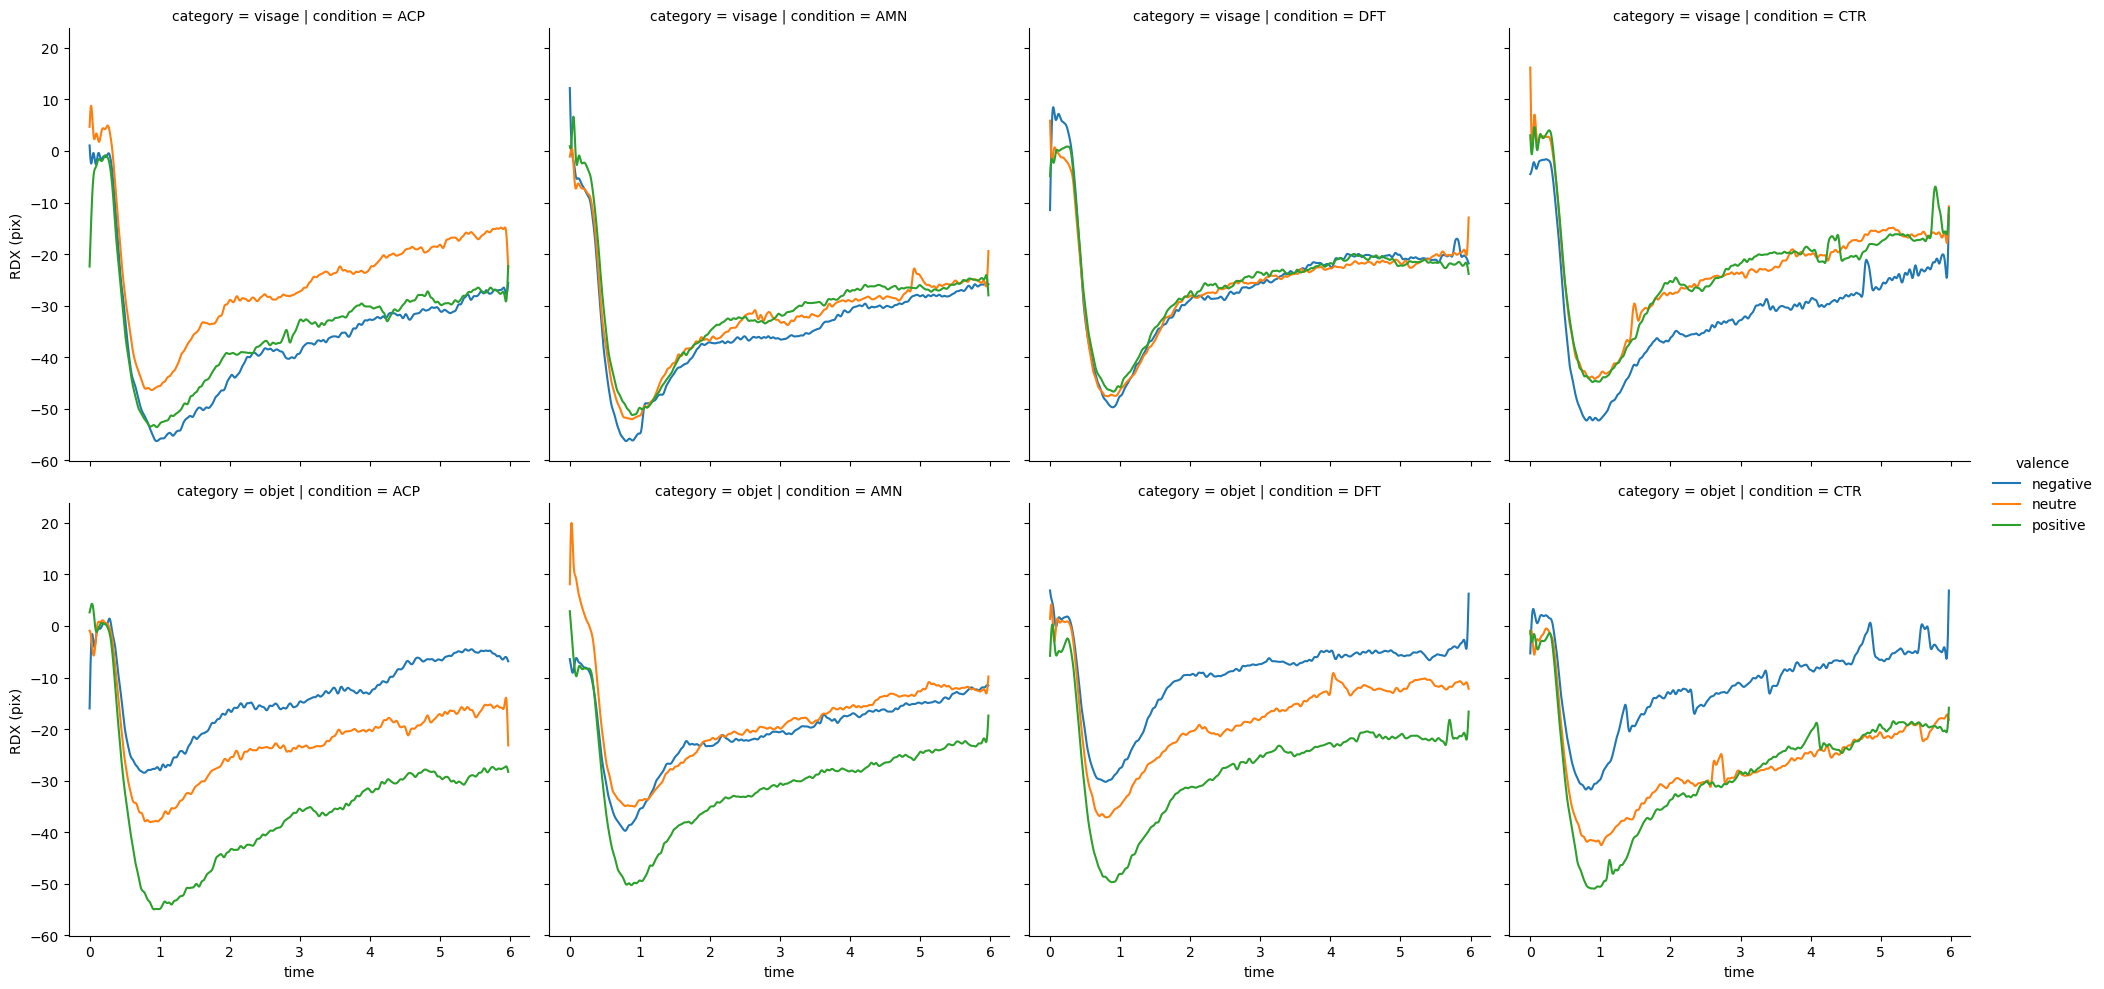

In [ ]:
all_data
sns.relplot(all_data, x='time', y='RDX (pix)', col='condition', hue='valence', row='category', kind='line', errorbar=None)

In [225]:
all_data.to_csv('2026_07_03_data_timeseries.csv', index=False)

In [548]:
data_all = pd.DataFrame()
data_all = pd.concat([pca_data, amn_data, dft_data, ctr_data])

In [552]:
data_all['gradient'] = data_all['D_1']/data_all['tau_1']
data_all['amplitude'] = data_all['D_1']*(data_all['tau_2']/(np.e*data_all['tau_1']))

In [572]:
def normalise(data, param):
    mean = np.mean(data[param][(data['valence']=='neutre') & (data['condition']=='CTR')])
    std = np.std(data[param][(data['valence']=='neutre') & (data['condition']=='CTR')])
    data[f'{param}_zscore'] = (data[param] - mean)/std
    return data

In [579]:
data_all['tau_2/tau_1'] = data_all['tau_2'] / data_all['tau_1']

In [580]:
columns_to_normalise = list(data_all.columns.values)[6:]
for i in columns_to_normalise:
    data_all = normalise(data_all, i)

In [34]:
from scipy.stats import mannwhitneyu
from statannotations.Annotator import Annotator
from itertools import combinations

In [35]:
def plot_all_conditions(data, y, x, hue, test, letter, xlabel, ylabel):
    plotting_parameters = {
        'data': data,
        'x': x,
        'y': y,
        'hue': hue,
    }
    
    ax = sns.boxplot(**plotting_parameters, gap=.1, showfliers=False)

    cond = np.unique(data.loc[:, 'condition'])
    val = np.unique(data.loc[:, 'valence'])
    
    pair = []
    for i in cond:
        if len(val) == 1:
            pair.append(i)
        else:
            for j in val:
                pair.append((i, j))
    pairs = list(combinations(pair, r=2))
    
    annotator = Annotator(ax, pairs=pairs, **plotting_parameters)
    annotator.configure(test=test, hide_non_significant=True).apply_and_annotate()

    try:
        sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    except ValueError:
        pass

    ax.set(xlabel=xlabel, ylabel=ylabel)
    ax.text(-0.04, 1.05, letter, transform=ax.transAxes, fontsize=13, fontweight='bold', va='top', ha='right')
    sns.despine()
    plt.tight_layout()
    plt.show()

### Classify using Random Forest

In [704]:
X = data_all.loc[:, ['valence', 'category', 'mean_variation', 'D_1', 't_0', 'tau_1', 'tau_2', 'amplitude',
       'gradient']]

In [705]:
X['category'] = X['category'].map({'visage': 0, 'objet': 1})
X = pd.get_dummies(X, columns=['valence'], dtype=int)

In [706]:
y = data_all.iloc[:, 1]

In [707]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit

In [708]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# groups = data_all['id']
# gss = GroupShuffleSplit(n_splits=1, train_size=0.8)
# train_idx, test_idx = next(gss.split(X, y, groups=groups))

# X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
# y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [709]:
from sklearn.ensemble import RandomForestClassifier

In [710]:
rf = RandomForestClassifier(
    n_estimators=3000
)

In [711]:
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=3000)

In [712]:
y_pred = rf.predict(X_test)

In [703]:
rf.score(X_test, y_test)

0.7847222222222222

In [713]:
from sklearn.metrics import classification_report

In [714]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         AMN       0.74      0.75      0.75        93
         CTR       0.80      0.67      0.73        54
         DFT       0.68      0.87      0.76        85
         PCA       0.88      0.62      0.73        56

    accuracy                           0.75       288
   macro avg       0.77      0.73      0.74       288
weighted avg       0.76      0.75      0.75       288



In [715]:
features = pd.DataFrame(rf.feature_importances_, index = X.columns)

In [729]:
features.index

Index(['category', 'mean_variation', 'D_1', 't_0', 'tau_1', 'tau_2',
       'amplitude', 'gradient', 'valence_negative', 'valence_neutre',
       'valence_positive'],
      dtype='object')

In [995]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [774]:
np.unique(y_pred)

array(['AMN', 'CTR', 'DFT', 'PCA'], dtype=object)

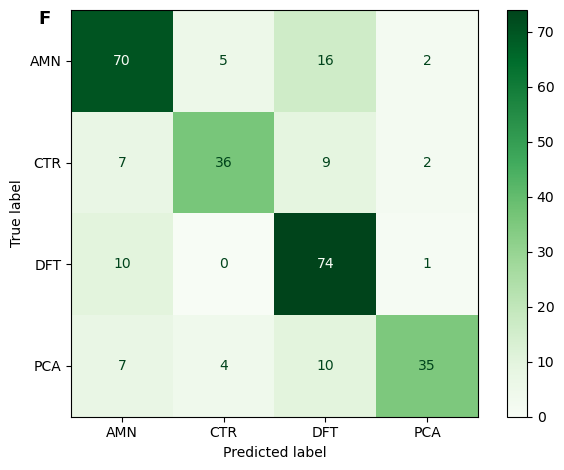

In [1000]:
matrix = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=rf.classes_)
disp.plot(cmap=plt.cm.Greens)


ax=disp.ax_


# ax = sns.heatmap(matrix, annot=True, cmap=plt.cm.Greens)

# class_names = y.unique()
# tick_marks = np.arange(len(class_names)) + 0.5
ax.text(-0.05, 1.00, 'F', transform=ax.transAxes, fontsize=13, fontweight='bold', va='top', ha='right')
# plt.xticks(tick_marks, class_names, rotation=25)
# plt.yticks(tick_marks, class_names, rotation=25)


plt.tight_layout()
plt.show()

In [765]:
y.unique()

array(['PCA', 'AMN', 'DFT', 'CTR'], dtype=object)

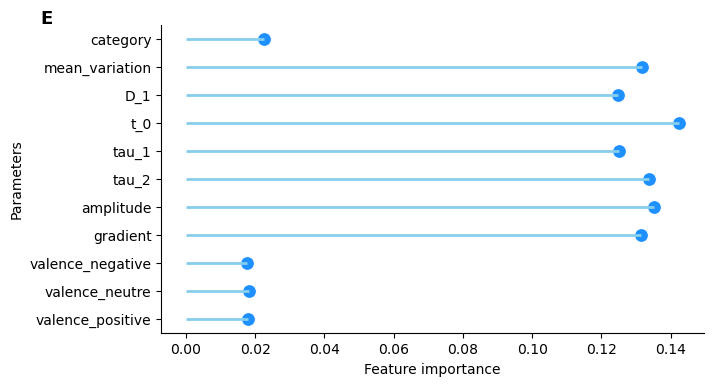

In [992]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hlines(y=features.index, xmin=0, xmax=features.values, color='skyblue', linewidth=2)

# # 2. Draw the lollipops (dots)
sns.scatterplot(x=features.values[:,0], y=features.index, color='dodgerblue', s=100, ax=ax)
ax.set_xlabel('Feature importance')
ax.set_ylabel('Parameters')
ax.text(-0.20, 1.05, 'E', transform=ax.transAxes, fontsize=13, fontweight='bold', va='top', ha='right')
sns.despine()

### Expxloring data

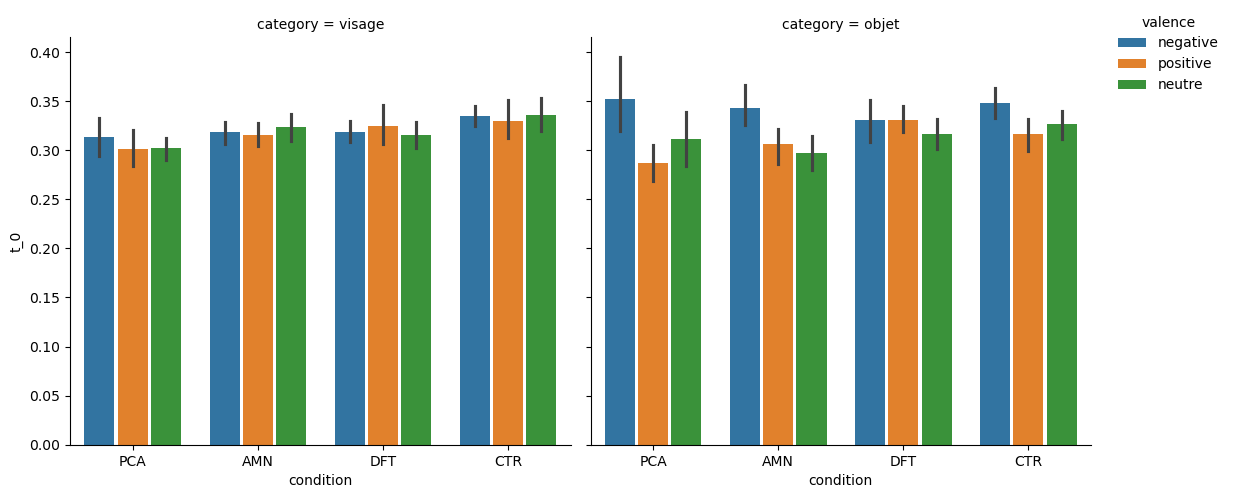

In [45]:
ax = sns.catplot(
    data=data_all,
    x='condition', y='t_0', hue='valence',
    col='category',
    kind='bar', gap=.1
)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

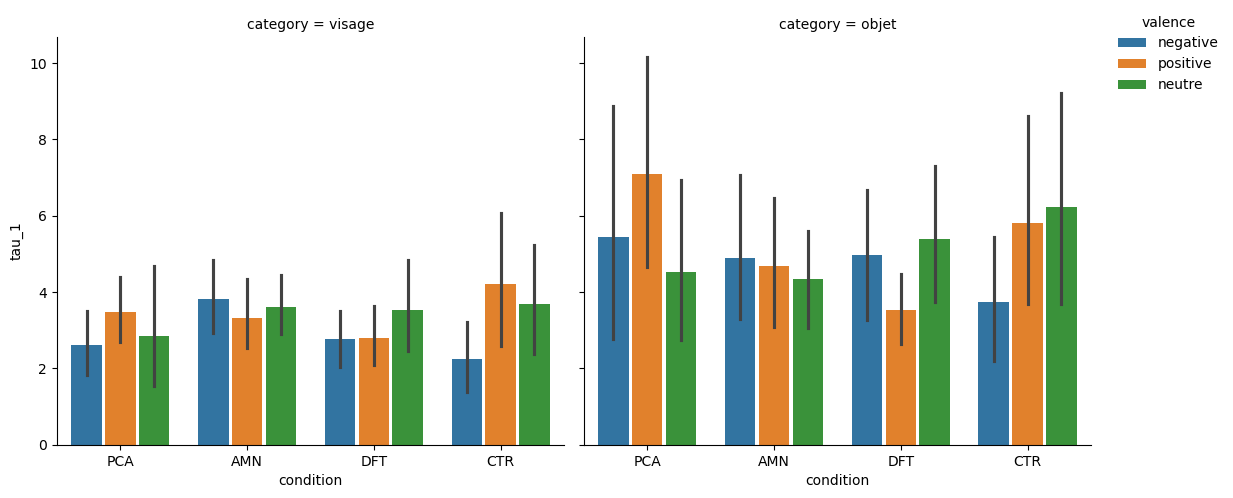

In [46]:
ax = sns.catplot(
    data=data_all,
    x='condition', y='tau_1', hue='valence',
    col='category',
    kind='bar', gap=.1
)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

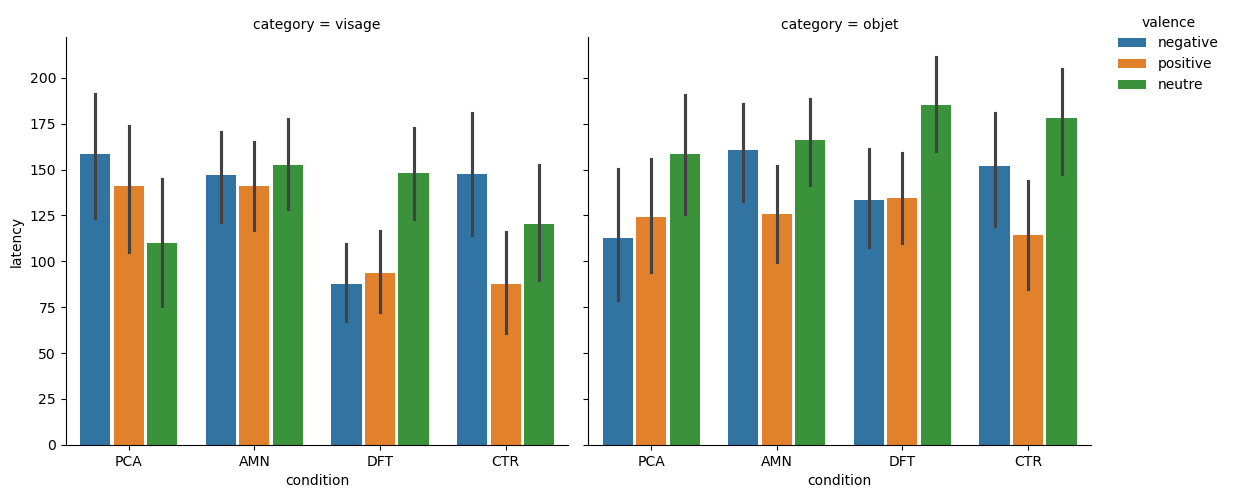

In [51]:
ax = sns.catplot(
    data=data_all,
    x='condition', y='latency', hue='valence',
    col='category',
    kind='bar', gap=.1
)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

In [536]:
final_series

,condition,valence,category,time_series,time,cond_category
0,dft,negative,visage,-0.204691,0.000000,0
1,dft,negative,visage,-0.285128,0.003335,0
2,dft,negative,visage,-0.361294,0.006670,0
3,dft,negative,visage,-0.430713,0.010006,0
4,dft,negative,visage,-0.491351,0.013341,0
...,...,...,...,...,...,...
43003,pca,neutre,objet,-20.709495,5.959993,0
43004,pca,neutre,objet,-21.156367,5.963328,0
43005,pca,neutre,objet,-21.652041,5.966663,0
43006,pca,neutre,objet,-22.180922,5.969998,0


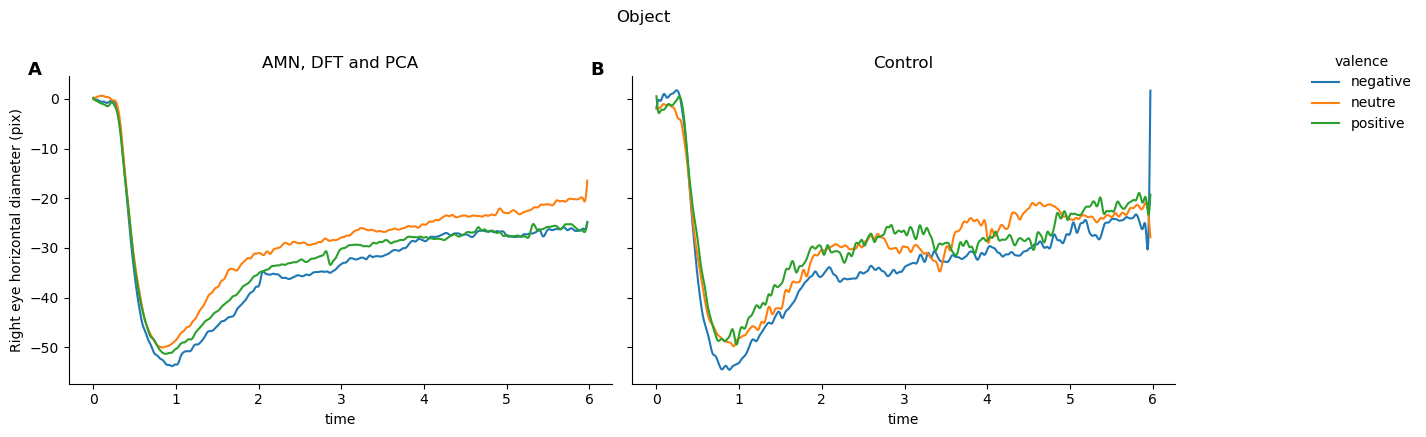

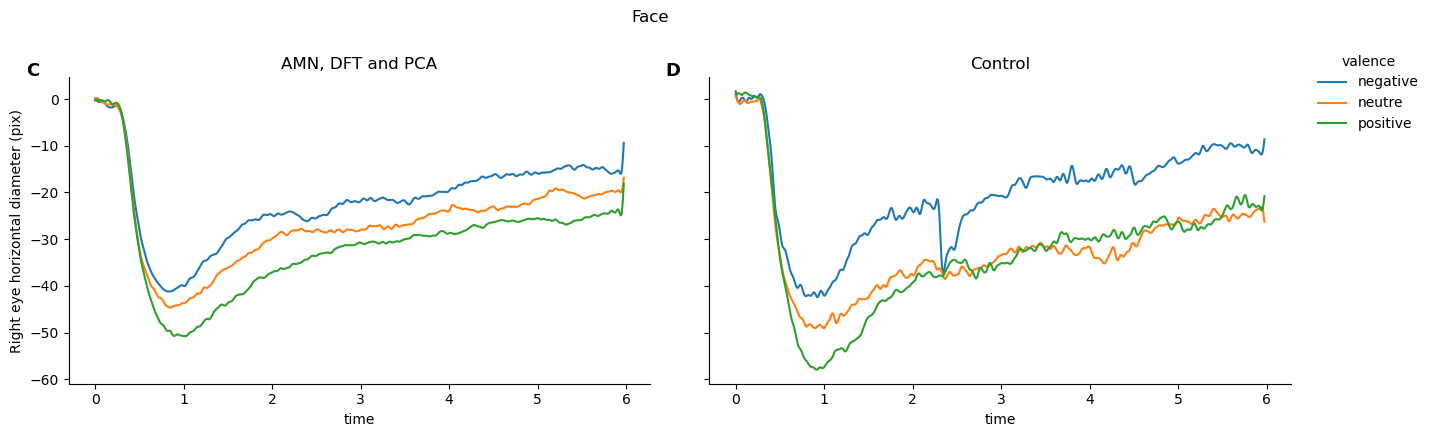

In [537]:
p1 = sns.relplot(
    data=final_series[final_series['category']=='visage'],
    x='time', y='time_series', hue='valence',
    col='cond_category',
    kind='line', errorbar=None, 
    height=4, aspect=1.5
)

p2 = sns.relplot(
    data=final_series[final_series['category']=='objet'],
    x='time', y='time_series', hue='valence',
    col='cond_category',
    kind='line', errorbar=None, 
    height=4, aspect=1.5
)

# ax1 = p1.axes[0]
# ax2 = p2.axes[0]



ax1_left = p1.axes[0, 0]   # First subplot (left)
ax1_right = p1.axes[0, 1]  # Second subplot (right)

ax2_left = p2.axes[0, 0]   # First subplot (left)
ax2_right = p2.axes[0, 1]  # Second subplot (right)

# Add text labels to each subplot
ax1_left.text(-0.05, 1.05, 'A', transform=ax1_left.transAxes, fontsize=13, fontweight='bold', va='top', ha='right')
ax1_right.text(-0.05, 1.05, 'B', transform=ax1_right.transAxes, fontsize=13, fontweight='bold', va='top', ha='right')

sns.move_legend(p1, "upper left", bbox_to_anchor=(1, 1))
p1.set(ylabel='Right eye horizontal diameter (pix)')
plt.tight_layout()

ax2_left.text(-0.05, 1.05, 'C', transform=ax2_left.transAxes, fontsize=13, fontweight='bold', va='top', ha='right')
ax2_right.text(-0.05, 1.05, 'D', transform=ax2_right.transAxes, fontsize=13, fontweight='bold', va='top', ha='right')

sns.move_legend(p2, "upper left", bbox_to_anchor=(1, 1))
p2.set(ylabel='Right eye horizontal diameter (pix)')
plt.tight_layout()

ax1_left.set_title("AMN, DFT and PCA")
ax1_right.set_title("Control")
ax2_left.set_title("AMN, DFT and PCA")
ax2_right.set_title("Control")
plt.tight_layout()

p1.fig.suptitle('Object', y=1.08)
p2.fig.suptitle('Face', y=1.08)
plt.tight_layout

p1.fig.savefig('Object.png', dpi=600, bbox_inches='tight')
p2.fig.savefig('Face.png', dpi=600, bbox_inches='tight')

In [167]:
sns.relplot(final_series, x='time', y='time_series', col='condition', row='category', hue='valence', kind='line', height=4)
plt.tight_layout()

NameError: name 'final_series' is not defined

In [604]:
# all_timeseries = all_timeseries.drop(columns='trial')
# b = all_timeseries.groupby(['valence', 'category', 'condition', 'time']).mean().reset_index()
# b.to_csv('2026_06_23_data_timeseries.csv', index=False)

KeyError: "None of [Index([2, 4], dtype='int64')] are in the [columns]"

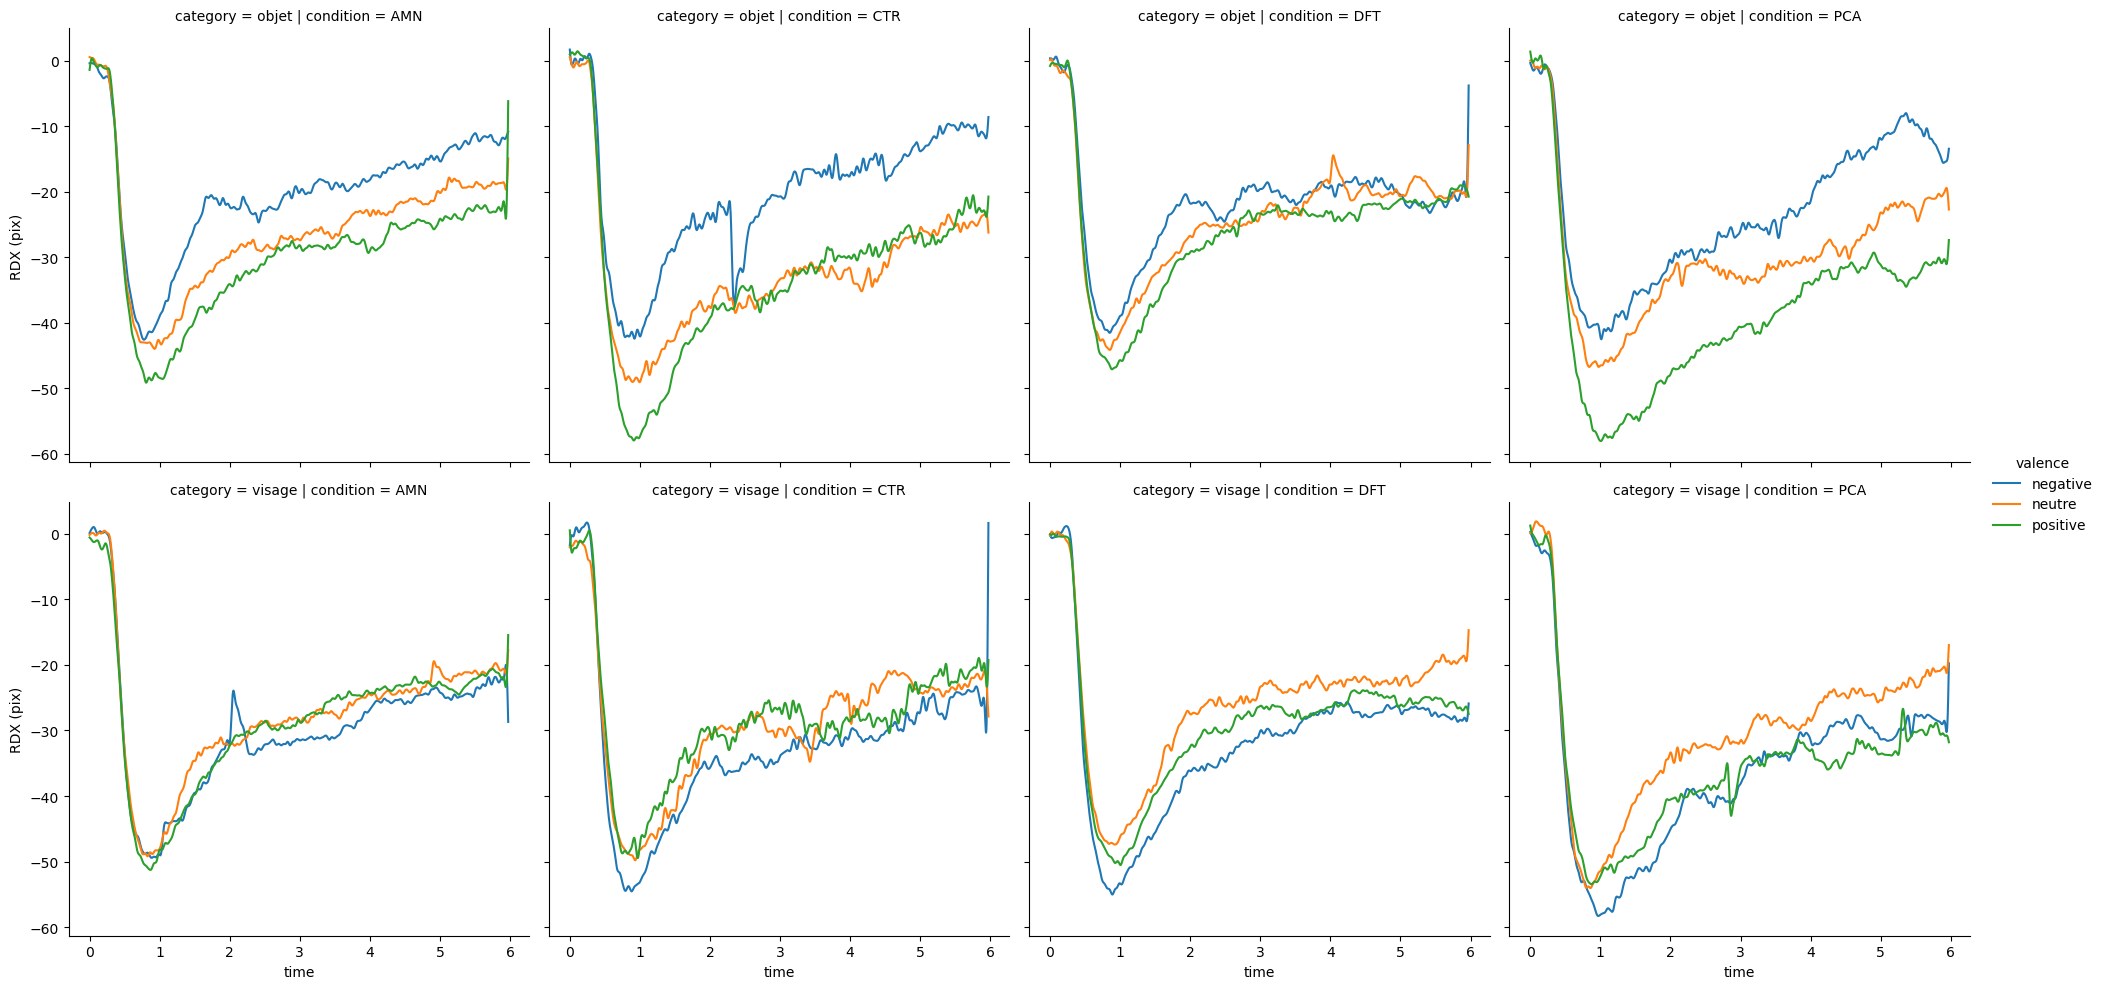

In [57]:
g = sns.relplot(timeseries, x='time', y='RDX (pix)', col='condition', row='category', hue='valence', kind='line')
g.map(plt.scatter, 2, 4, color='blue', s=100, zorder=5)
plt.show()

In [601]:
b.to_csv('2026_06_23_data_timeseries.csv', index=False)

In [168]:
timeseries = pd.read_csv('/Users/arthu/Documents/Marseille/aMU/M1/Stage/2026_06_24_data_timeseries.csv')

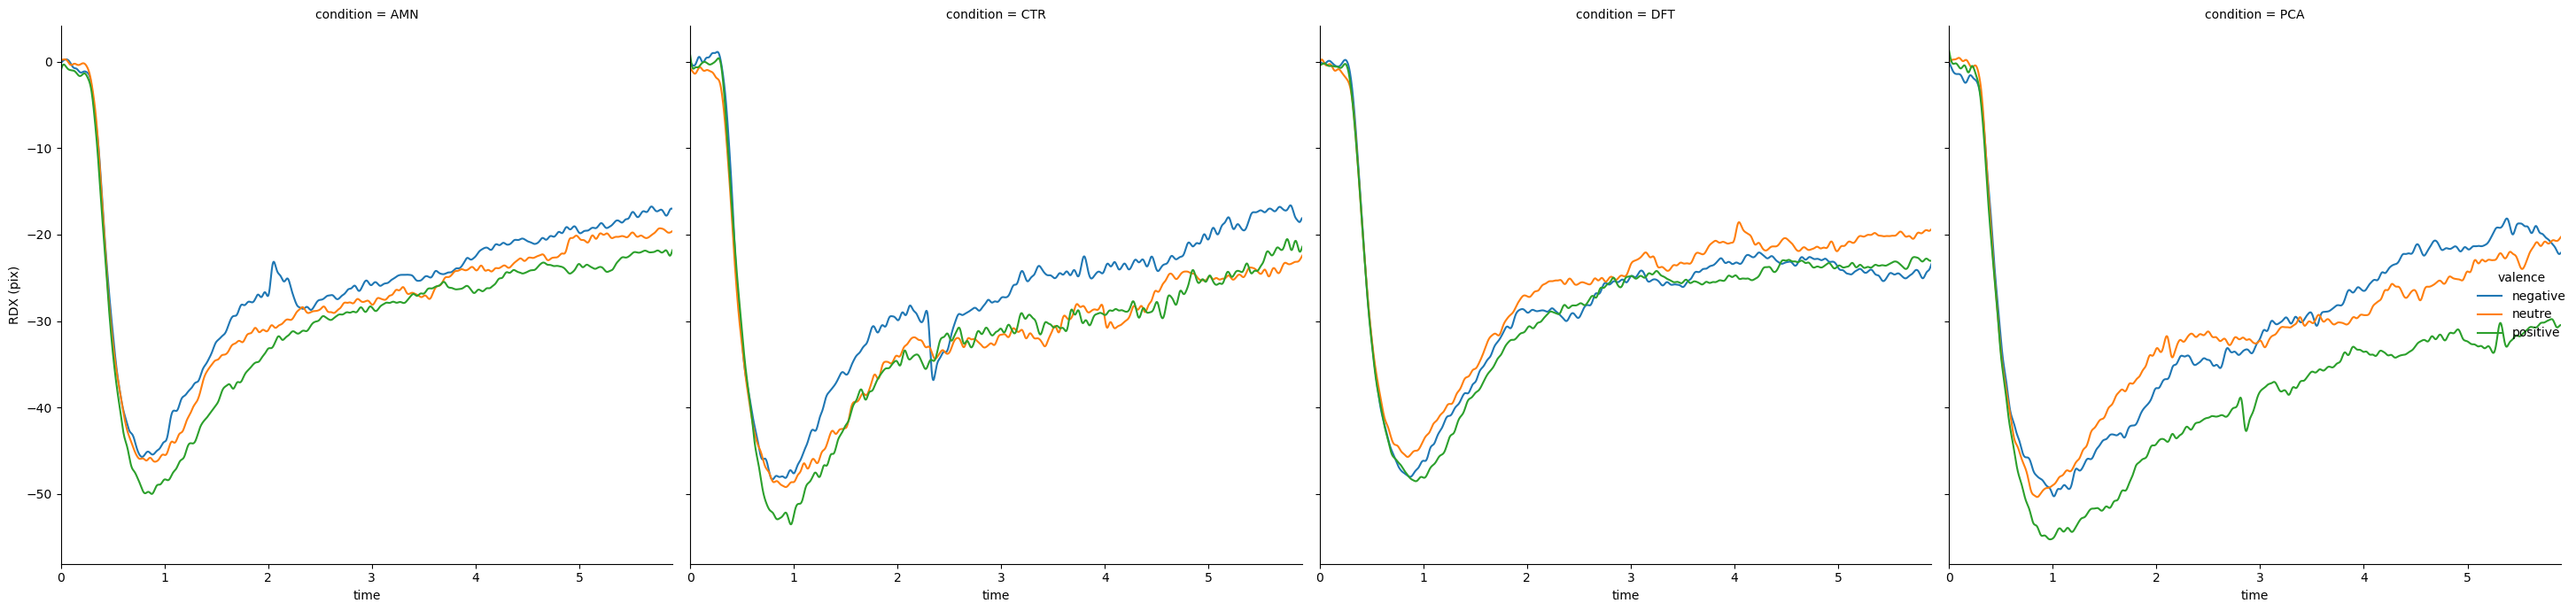

In [169]:
sns.relplot(timeseries, x='time', y='RDX (pix)', col='condition', hue='valence', kind='line', errorbar=None, height=7)
plt.xlim(0, 5.9)
plt.tight_layout()

In [10]:
# param = pd.read_csv('/Users/arthu/Documents/Marseille/aMU/M1/Stage/2026_06_19_data_params.csv')
sns.lineplot

,valence,category,condition,time,LDX (pix),LDY (pix),RDX (pix),RDY (pix)
0,negative,objet,AMN,0.000000,0.056123,-1.713739,-0.409503,-0.535142
1,negative,objet,AMN,0.003335,-0.048507,-1.581510,-0.404613,-0.425795
2,negative,objet,AMN,0.006670,-0.149862,-1.456773,-0.399465,-0.322105
3,negative,objet,AMN,0.010006,-0.244029,-1.343910,-0.394087,-0.227287
4,negative,objet,AMN,0.013341,-0.327784,-1.246487,-0.388670,-0.143837


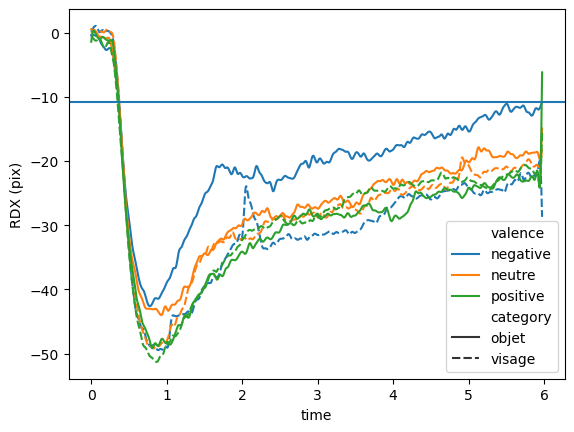

In [85]:
g = sns.lineplot(timeseries[timeseries['condition']=='AMN'], x='time', y='RDX (pix)', hue='valence', style='category', errorbar=None)
g.axhline(y=-10.838777)

In [158]:
min_curve = timeseries.groupby(['valence', 'category', 'condition']).min().reset_index().drop(columns='time')
max_curve = timeseries[(timeseries['time']>1) & (timeseries['time']<5.9)].groupby(['valence', 'category', 'condition']).max().reset_index().drop(columns='time')

In [159]:
ratio = min_curve.copy()
for i in ratio.columns.values:
    if isinstance(ratio[i][0], float):
        ratio[f'{i}_ratio'] = max_curve[i]/min_curve[i]

In [163]:
g = sns.catplot(
    data=ratio, x="valence", y="LDX (pix)_ratio", hue="condition",
    capsize=.2, kind="point", height=5, aspect=1.5, errorbar=None
)
g.despine()
g.set(ylabel='ratio of maximum to minimum pupil diameter (RDX)')
plt.tight_layout()

NameError: name 'ratio' is not defined

In [150]:
timeseries.groupby(['valence', 'category', 'condition']).mean().reset_index().drop(columns='time')

,valence,category,condition,LDX (pix),LDY (pix),RDX (pix),RDY (pix)
0,negative,objet,AMN,-20.104833,-22.279478,-20.077349,-22.262229
1,negative,objet,CTR,-22.188492,-25.934354,-20.190663,-25.174740
2,negative,objet,DFT,-22.607596,-25.942291,-22.117097,-23.896444
3,negative,objet,PCA,-22.985211,-26.657195,-23.054736,-24.155113
4,negative,visage,AMN,-32.426761,-29.864598,-29.367572,-29.770898
5,negative,visage,CTR,-32.157531,-31.825707,-32.350421,-31.292779
6,negative,visage,DFT,-32.795671,-33.866545,-31.849087,-33.544966
7,negative,visage,PCA,-37.258831,-33.578815,-36.102844,-33.730877
8,neutre,objet,AMN,-26.626371,-27.436437,-25.721368,-25.722872
9,neutre,objet,CTR,-32.392473,-31.627995,-32.116158,-30.622542


In [164]:
all_data = pd.read_csv('/Users/arthu/Documents/Marseille/aMU/M1/Stage/2026_07_03_data_timeseries.csv').drop(columns='trial')

In [165]:
data = all_data.groupby(['id', 'condition', 'valence', 'category', 'time']).mean().reset_index()

In [166]:
data_min = data[(data.time >= 0.5)& (data.time <= 2.0)].groupby(['condition', 'valence', 'category']).min().reset_index().drop(columns=['time'])
data_max = data[(data.time >= 2.0)& (data.time <= 5.5)].groupby(['condition', 'valence', 'category']).max().reset_index().drop(columns=['time'])
data_dif = data_min.loc[:, ['LDX (pix)', 'LDY (pix)', 'RDX (pix)', 'RDY (pix)']]-data_max.loc[:, ['LDX (pix)', 'LDY (pix)', 'RDX (pix)', 'RDY (pix)']]
data_dif[['id', 'condition', 'valence', 'category']] = data_min[['id', 'condition', 'valence', 'category']]

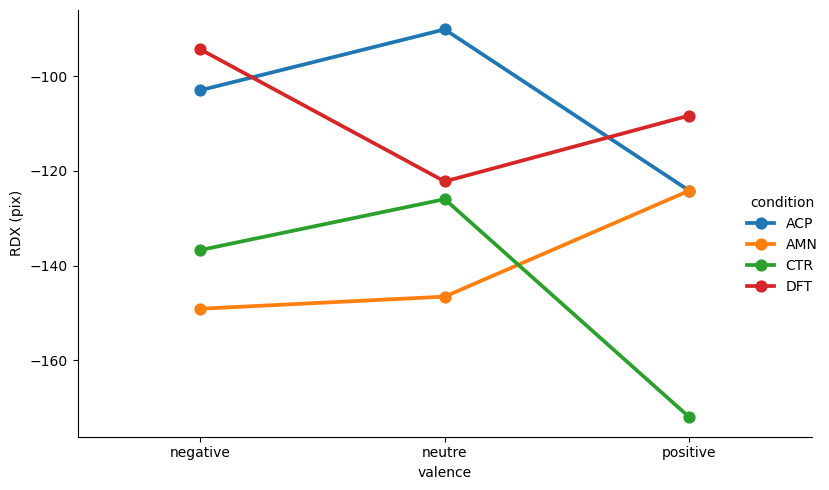

In [168]:
g = sns.catplot(
    data=data_dif, x="valence", y="RDX (pix)", hue="condition",
    capsize=.2, kind="point", height=5, aspect=1.5, errorbar=None
)
g.despine()
plt.tight_layout()

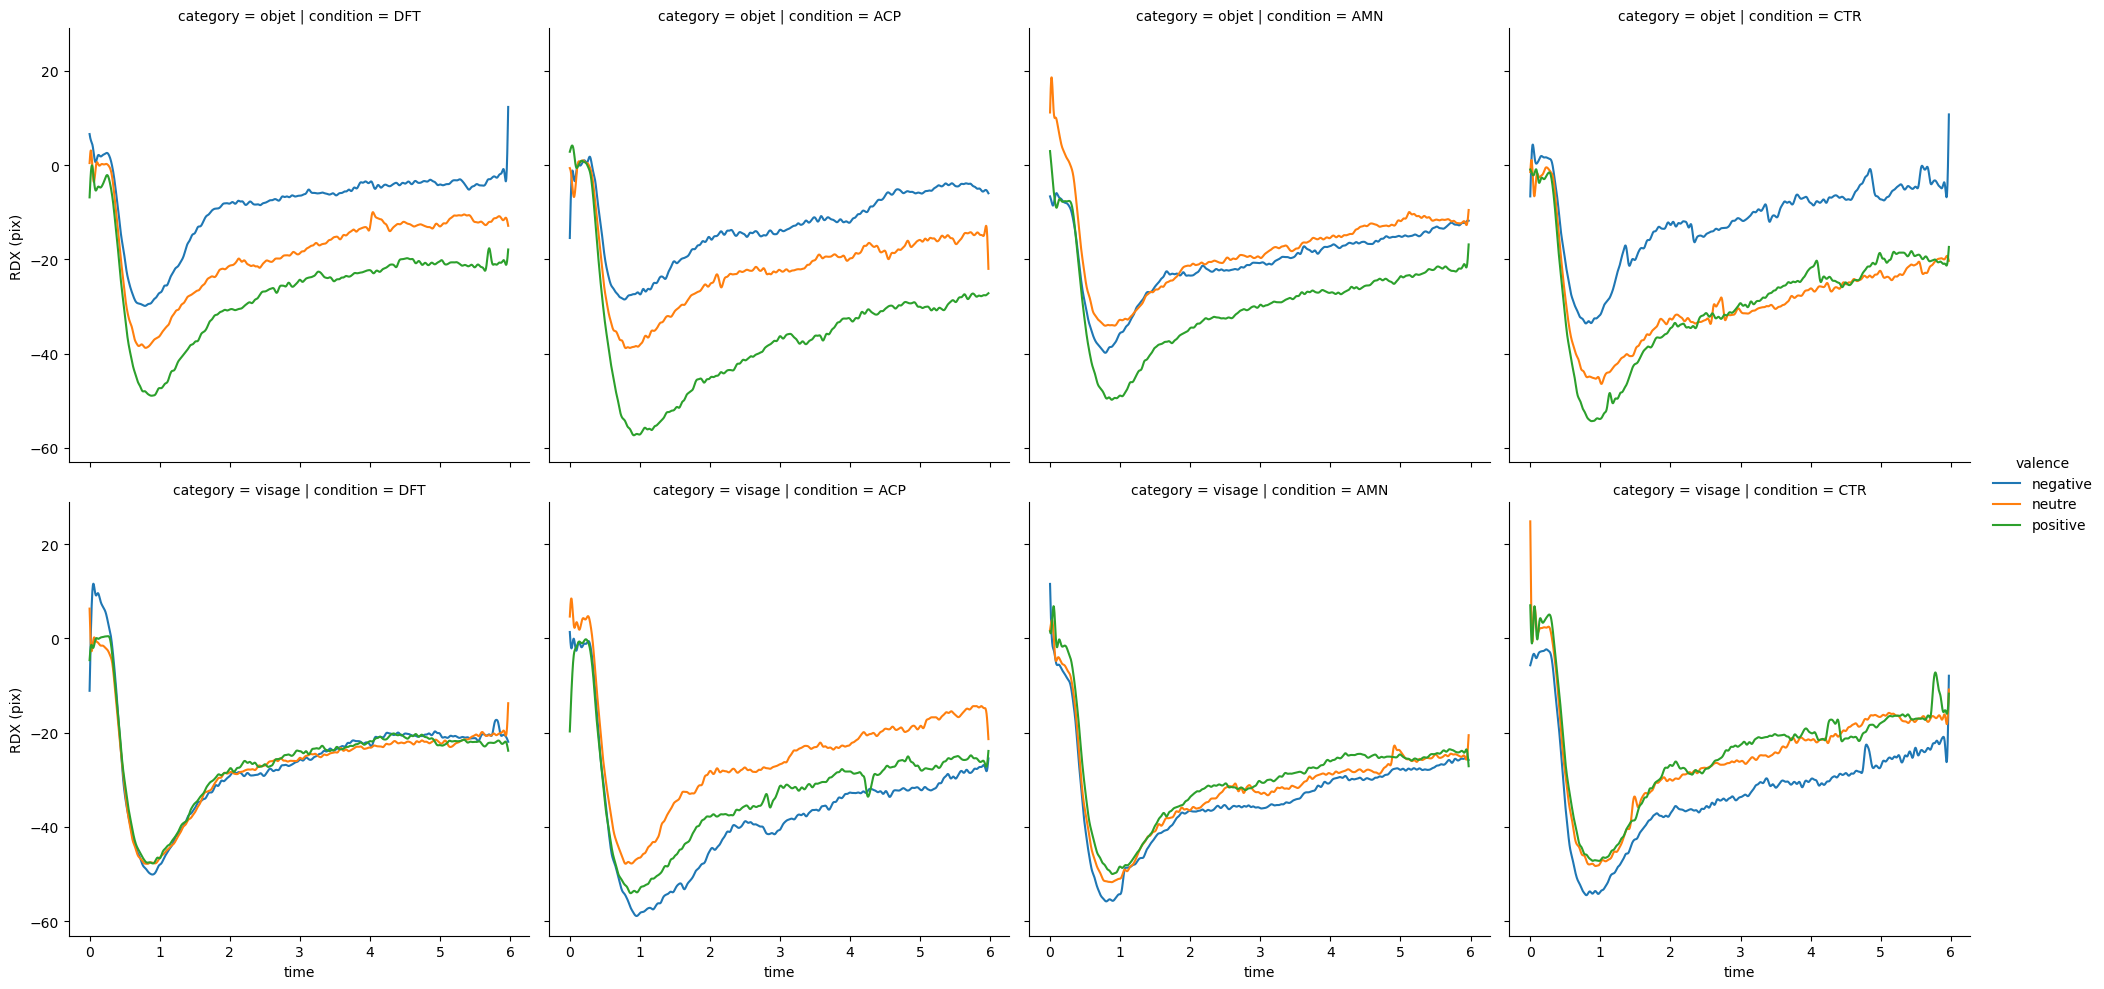

In [176]:
data
sns.relplot(data, x='time', y='RDX (pix)', col='condition', row='category', hue='valence', errorbar=None, kind='line')